In [1]:
!pip install beautifulsoup4 pandas openpyxl requests


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

titles = []
prices = []
ratings = []

for page in range(1, 51):
    url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    books = soup.find_all("article", class_="product_pod")

    for book in books:
        titles.append(book.h3.a["title"])
        prices.append(book.find("p", class_="price_color").text)
        ratings.append(book.p["class"][1])

df = pd.DataFrame({
    "Title": titles,
    "Price": prices,
    "Rating": ratings
})

df.to_excel("books_dataset.xlsx", index=False)

print("Dataset Saved!")
print("Total Records:", len(df))

df.head()

Dataset Saved!
Total Records: 1000


,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


In [3]:
from google.colab import files

files.download("books_dataset.xlsx")

ModuleNotFoundError: No module named 'google'

In [ ]:
df.info()
df.describe()
df["Rating"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   1000 non-null   object
 1   Price   1000 non-null   object
 2   Rating  1000 non-null   object
dtypes: object(3)
memory usage: 23.6+ KB


,count
Rating,
One,226
Three,203
Five,196
Two,196
Four,179


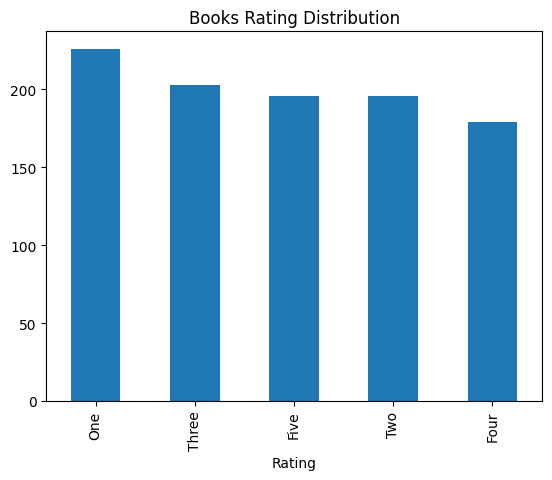

In [ ]:
import matplotlib.pyplot as plt

df["Rating"].value_counts().plot(kind="bar")
plt.title("Books Rating Distribution")
plt.show()